### PCA sensory


C:\Users\david\AppData\Local\Temp\ipykernel_41048\2361432098.py:50: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(pc_df.PC1[i], pc_df.PC2[i], sample, fontsize=8, ha='right', va='bottom')


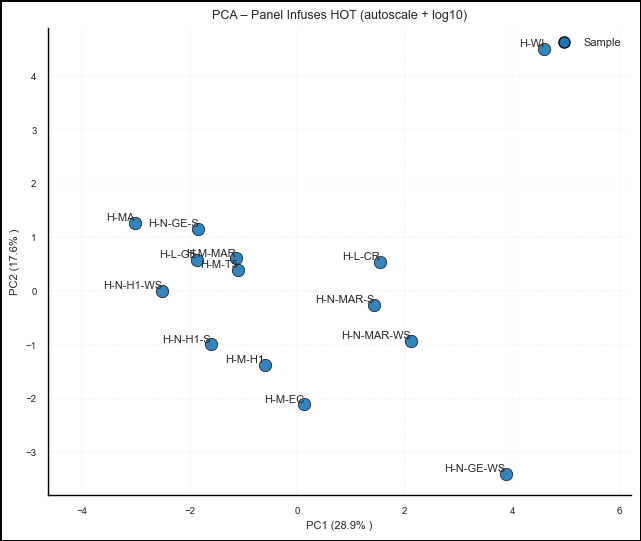

C:\Users\david\AppData\Local\Temp\ipykernel_41048\2361432098.py:50: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(pc_df.PC1[i], pc_df.PC2[i], sample, fontsize=8, ha='right', va='bottom')


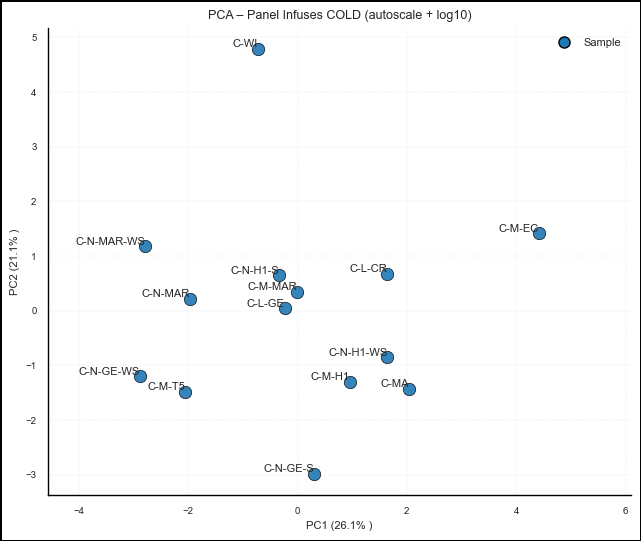

C:\Users\david\AppData\Local\Temp\ipykernel_41048\2361432098.py:98: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(pc_df.PC1[i], pc_df.PC2[i], sample, fontsize=8, ha='right', va='bottom')


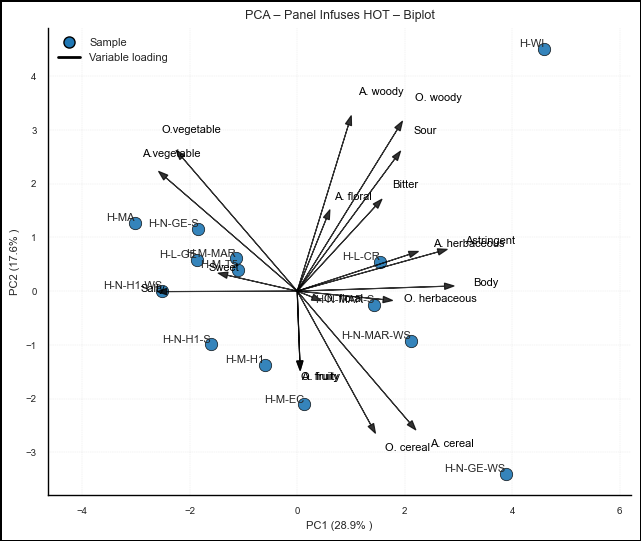

C:\Users\david\AppData\Local\Temp\ipykernel_41048\2361432098.py:98: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(pc_df.PC1[i], pc_df.PC2[i], sample, fontsize=8, ha='right', va='bottom')


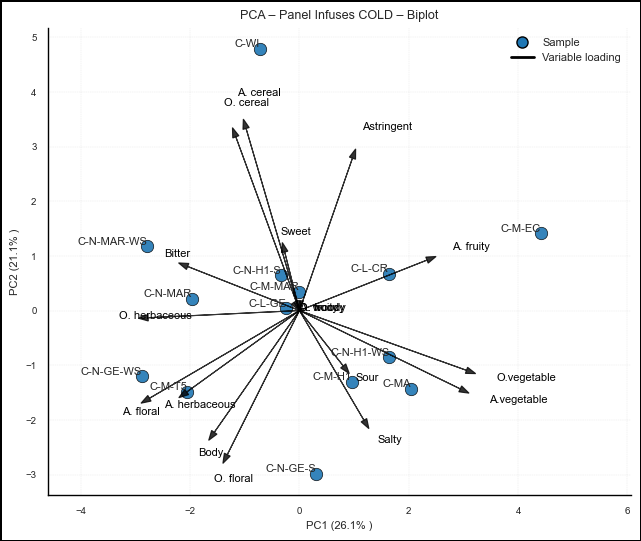


PCA analysis: PCA – Selected HOT Samples
Sample points analyzed: ['H-MA', 'H-M-EC', 'H-M-T5', 'H-N-GE-WS', 'H-WI']
Explained variance per component:
  Component 1: 40.51%
  Component 2: 25.64%
  Component 3: 22.23%
  Component 4: 11.62%
  Component 5: 0.00%
Total first 2 components: 66.15%


C:\Users\david\AppData\Local\Temp\ipykernel_41048\2361432098.py:184: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(pc_df.PC1[i], pc_df.PC2[i], sample,


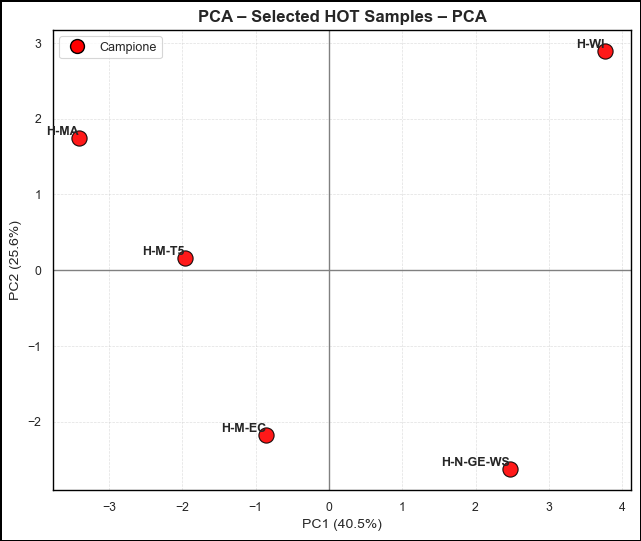


PCA analysis: PCA – Selected COLD Samples
Sample points analyzed: ['C-MA', 'C-M-EC', 'C-M-T5', 'C-N-GE-WS', 'C-WI']
Explained variance per component:
  Component 1: 39.09%
  Component 2: 29.57%
  Component 3: 18.01%
  Component 4: 13.33%
  Component 5: 0.00%
Total first 2 components: 68.67%


C:\Users\david\AppData\Local\Temp\ipykernel_41048\2361432098.py:184: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(pc_df.PC1[i], pc_df.PC2[i], sample,


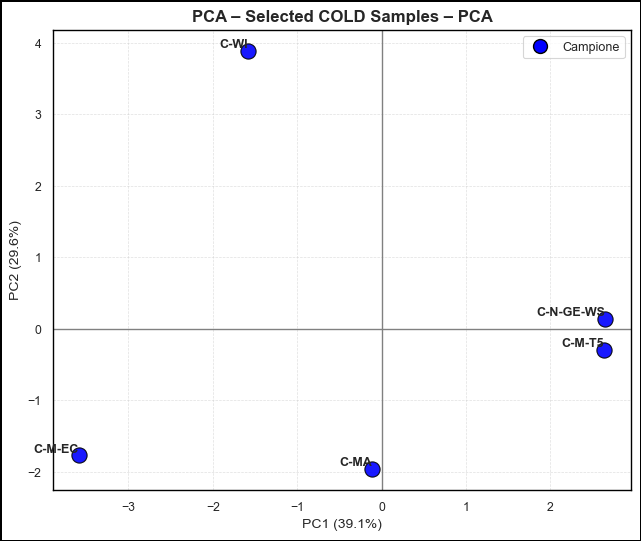

In [ ]:
import pandas as pd
import numpy as np
import prince
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# === Lettura dati panel =========================================================
panel_path = r"C:\Users\david\OneDrive - Università degli Studi di Parma\PhD\Projects\Coffee_leaf_infuses\data\processed\paneldata_infuses_full.csv"
panel_df = pd.read_csv(panel_path, index_col=0)

# === Separa infusi caldi e freddi ===============================================
hot_panel = panel_df[panel_df.index.str.startswith("H-")]
cold_panel = panel_df[panel_df.index.str.startswith("C-")]

def autoscale_log(df):
    log_df = np.log10(df + 1)
    scaled = StandardScaler().fit_transform(log_df)
    return pd.DataFrame(scaled, index=df.index, columns=df.columns)

# === PCA stile minimal (come volatilome) ========================================
def run_pca_panel(df, title, save_prefix):
    df_scaled = autoscale_log(df)
    pca = PCA()
    pcs = pca.fit_transform(df_scaled.values)
    pc_df = pd.DataFrame(pcs[:, :2], index=df_scaled.index, columns=["PC1", "PC2"])

    sns.set_theme(style="white", context="paper")
    fig, ax = plt.subplots(figsize=(6.5, 5.5), facecolor='white')
    fig.patch.set_edgecolor('black')
    fig.patch.set_linewidth(1)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1)

    scatter = sns.scatterplot(
        data=pc_df,
        x="PC1",
        y="PC2",
        s=80,
        edgecolor="black",
        linewidth=0.5,
        alpha=0.9,
        ax=ax,
        legend=False,
        color="tab:blue"
    )
    for i, sample in enumerate(pc_df.index):
        ax.text(pc_df.PC1[i], pc_df.PC2[i], sample, fontsize=8, ha='right', va='bottom')

    ev = pca.explained_variance_ratio_ * 100
    ax.set_title(title, fontsize=9, pad=6)
    ax.set_xlabel(f"PC1 ({ev[0]:.1f}% )", fontsize=8)
    ax.set_ylabel(f"PC2 ({ev[1]:.1f}% )", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, linestyle="--", linewidth=0.3, alpha=0.5)
    ax.axis("equal")

    # Legenda
    from matplotlib.lines import Line2D
    handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue', markeredgecolor='black', markersize=8, label='Sample')]
    ax.legend(handles=handles, labels=['Sample'], loc='best', fontsize=8, frameon=False)
    sns.despine()
    plt.tight_layout()
    plt.savefig(f"outputs/{save_prefix}_panel_pca.jpg", dpi=600)
    plt.savefig(f"outputs/{save_prefix}_panel_pca.svg")
    plt.show()

# === PCA BIPLOT ================================================
def run_pca_biplot_panel(df, title, save_prefix):
    df_scaled = autoscale_log(df)
    pca = PCA()
    pcs = pca.fit_transform(df_scaled.values)
    pc_df = pd.DataFrame(pcs[:, :2], index=df_scaled.index, columns=["PC1", "PC2"])

    sns.set_theme(style="white", context="paper")
    fig, ax = plt.subplots(figsize=(6.5, 5.5), facecolor='white')
    fig.patch.set_edgecolor('black')
    fig.patch.set_linewidth(1)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1)

    scatter = sns.scatterplot(
        data=pc_df,
        x="PC1",
        y="PC2",
        s=80,
        edgecolor="black",
        linewidth=0.5,
        alpha=0.9,
        ax=ax,
        legend=False,
        color="tab:blue"
    )
    for i, sample in enumerate(pc_df.index):
        ax.text(pc_df.PC1[i], pc_df.PC2[i], sample, fontsize=8, ha='right', va='bottom')

    # Biplot: arrows per variabili (più lunghe e nere)
    loadings = pca.components_.T
    feature_names = df_scaled.columns
    arrow_scale = 8 # arrow length scaling factor
    for i, var in enumerate(feature_names):
        ax.arrow(0, 0, loadings[i, 0]*arrow_scale, loadings[i, 1]*arrow_scale,
                 color='black', alpha=0.8, head_width=0.12, length_includes_head=True, label='_var_arrow')
        ax.text(loadings[i, 0]*arrow_scale*1.12, loadings[i, 1]*arrow_scale*1.12, var, color='black', fontsize=8)

    # Legenda
    from matplotlib.lines import Line2D
    handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue', markeredgecolor='black', markersize=8, label='Sample'),
        Line2D([0], [0], color='black', lw=2, label='Variable loading')
    ]
    ax.legend(handles=handles, labels=['Sample', 'Variable loading'], loc='best', fontsize=8, frameon=False)

    ev = pca.explained_variance_ratio_ * 100
    ax.set_title(title + " – Biplot", fontsize=9, pad=6)
    ax.set_xlabel(f"PC1 ({ev[0]:.1f}% )", fontsize=8)
    ax.set_ylabel(f"PC2 ({ev[1]:.1f}% )", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, linestyle="--", linewidth=0.3, alpha=0.5)
    ax.axis("equal")
    sns.despine()
    plt.tight_layout()
    plt.savefig(f"outputs/{save_prefix}_panel_biplot.jpg", dpi=600)
    plt.savefig(f"outputs/{save_prefix}_panel_biplot.svg")
    plt.show()

# === Esegui PCA e BIPLOT per caldi e freddi =====================================
run_pca_panel(hot_panel, "PCA – Panel Infuses HOT (autoscale + log10)", "hot")
run_pca_panel(cold_panel, "PCA – Panel Infuses COLD (autoscale + log10)", "cold")
run_pca_biplot_panel(hot_panel, "PCA – Panel Infuses HOT", "hot")
run_pca_biplot_panel(cold_panel, "PCA – Panel Infuses COLD", "cold")


# === PCA su campioni selezionati (come volatilome) =============================
selected_samples = [
    "C-MA","C-M-EC","C-M-T5","C-N-GE-WS","C-WI",
    "H-MA","H-M-EC","H-M-T5","H-N-GE-WS","H-WI"
]

def run_pca_selected(df, sample_prefix, title, save_prefix):
    print(f"\n{'='*50}")
    print(f"PCA analysis: {title}")
    print(f"{'='*50}")
    
    # Filtra i campioni selezionati con prefisso specifico
    filtered = df.loc[[s for s in df.index if s in selected_samples and s.startswith(sample_prefix)]]
    print(f"Sample points analyzed: {filtered.index.tolist()}")
    
    # Autoscale + log10 come nel resto del codice
    df_scaled = autoscale_log(filtered)
    
    # PCA con sklearn
    pca = PCA()
    pcs = pca.fit_transform(df_scaled.values)
    pc_df = pd.DataFrame(pcs[:, :2], index=df_scaled.index, columns=["PC1", "PC2"])
    
    # Varianza spiegata
    ev = pca.explained_variance_ratio_ * 100
    print("Explained variance per component:")
    for i, var in enumerate(ev[:5]):
        print(f"  Component {i+1}: {var:.2f}%")
    print(f"Total first 2 components: {ev[:2].sum():.2f}%")
    
    # Plot PCA
    sns.set_theme(style="white", context="paper")
    fig, ax = plt.subplots(figsize=(6.5, 5.5), facecolor='white')
    fig.patch.set_edgecolor('black')
    fig.patch.set_linewidth(1)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1)
    
    color = "red" if sample_prefix == "H" else "blue"
    sns.scatterplot(
        data=pc_df,
        x="PC1", y="PC2",
        s=120, edgecolor="black", linewidth=0.8, alpha=0.9,
        ax=ax, color=color, label="Sample"
    )
    for i, sample in enumerate(pc_df.index):
        ax.text(pc_df.PC1[i], pc_df.PC2[i], sample,
                fontsize=9, ha='right', va='bottom', weight='bold')
    
    ax.set_title(f"{title} – PCA", fontsize=12, weight='bold')
    ax.set_xlabel(f"PC1 ({ev[0]:.1f}%)", fontsize=10)
    ax.set_ylabel(f"PC2 ({ev[1]:.1f}%)", fontsize=10)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    ax.axhline(0, color="grey", lw=1)
    ax.axvline(0, color="grey", lw=1)
    
    from matplotlib.lines import Line2D
    handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
               markeredgecolor='black', markersize=10, label='Campione')
    ]
    ax.legend(handles=handles, loc='best', fontsize=9, frameon=True)
    plt.tight_layout()
    
    plt.savefig(f"outputs/{save_prefix}_selected_panel_pca.jpg", dpi=600, bbox_inches='tight')
    plt.savefig(f"outputs/{save_prefix}_selected_panel_pca.svg", bbox_inches='tight')
    plt.show()

run_pca_selected(panel_df, "H", "PCA – Selected HOT Samples", "hot_selected")
run_pca_selected(panel_df, "C", "PCA – Selected COLD Samples", "cold_selected")


### MCA

Original dataset:
        O. herbaceous  O.vegetable  O. woody  O. cereal  O. floral  O. fruity  \
sample                                                                          
H-L-CR              0            1         0          0          3          0   
H-L-GE              2            5         0          0          0          0   
H-MA                1            4         0          0          0          0   
H-M-EC              4            1         0          0          1          1   
H-M-H1              1            2         0          1          0          0   

        Sour  Sweet  Salty  Bitter  Astringent  Body  A. herbaceous  \
sample                                                                
H-L-CR     1      0      0       2           3     2              0   
H-L-GE     0      2      1       0           2     2              1   
H-MA       0      2      2       1           1     1              1   
H-M-EC     0      1      1       0           2     2       

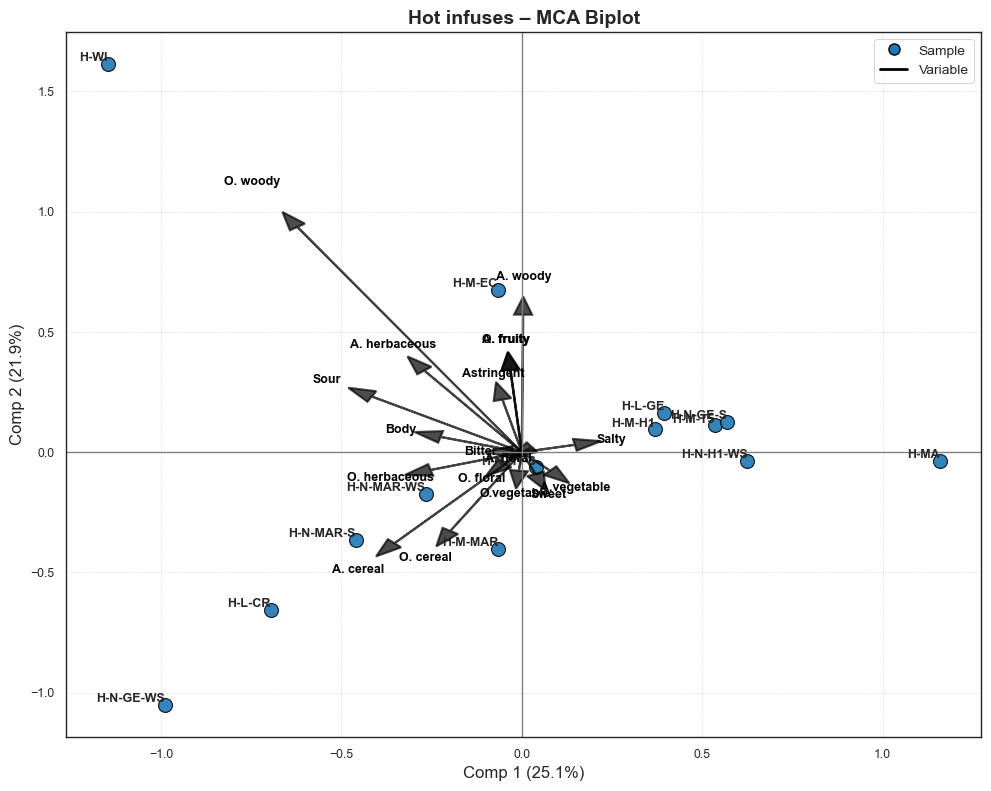


MCA analysis: Cold infuses
Explained variance per component:
  Component 1: 24.87%
  Component 2: 22.84%
  Component 3: 20.45%
  Component 4: 17.84%
  Component 5: 14.01%
Total first 2 components: 47.70%


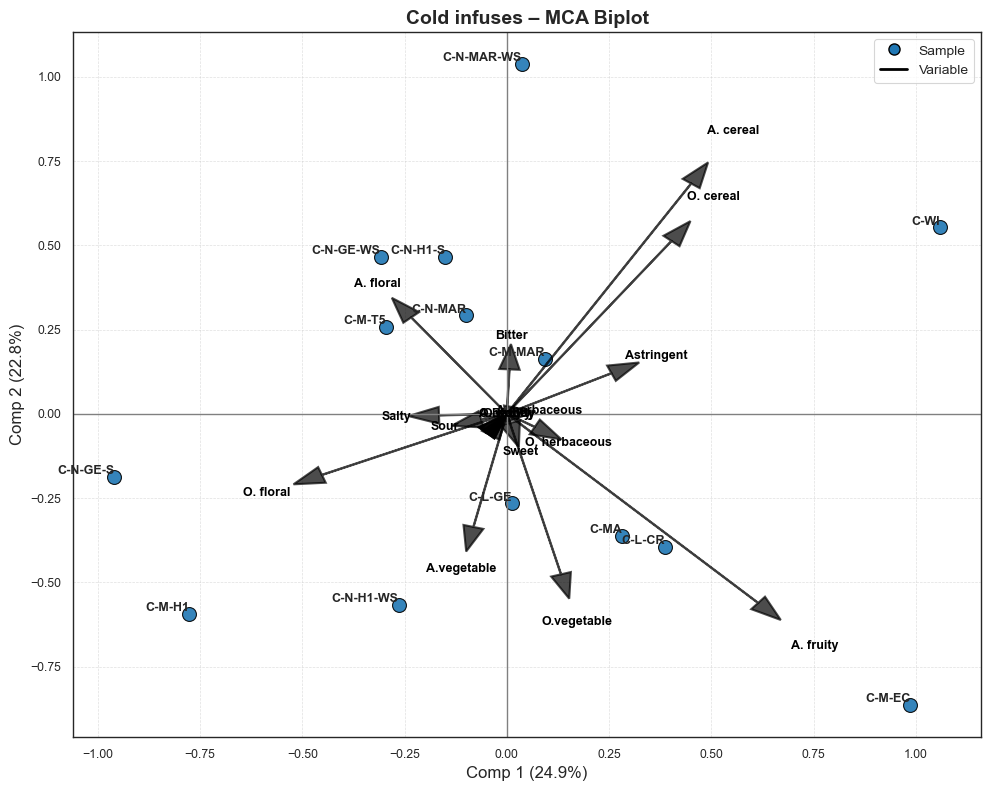


MCA analysis: Hot infuses selected
Sample points analyzed: ['H-MA', 'H-M-EC', 'H-M-T5', 'H-N-GE-WS', 'H-WI']
Explained variance per component:
  Component 1: 30.44%
  Component 2: 27.57%
  Component 3: 26.08%
  Component 4: 15.90%
Total first 2 components: 58.01%


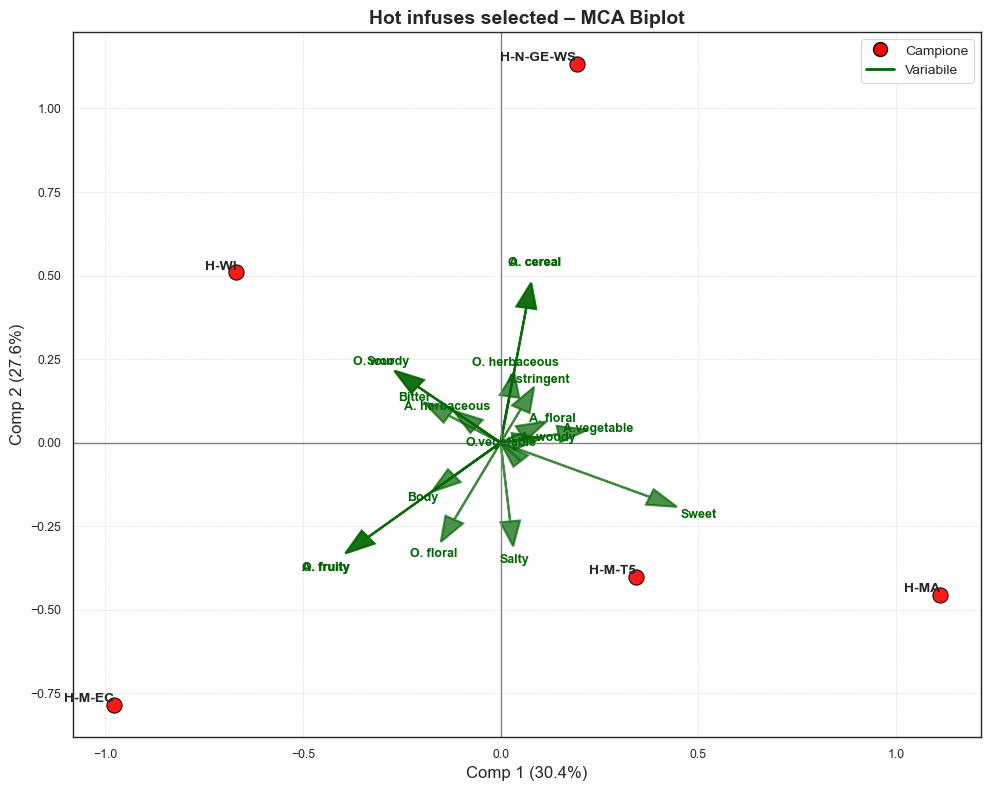


VARIABLE CONTRIBUTIONS

Top 10 variabiles Component 1:
  O.vegetable: 5.0000
  Salty: 3.9271
  A.vegetable: 3.7016
  Bitter: 3.5239
  Astringent: 3.2598
  A. woody: 3.0521
  Body: 2.7589
  Sweet: 2.3509
  O. herbaceous: 2.2254
  A. herbaceous: 2.0229

Top 10 variabiles Component 2:
  O.vegetable: 5.0000
  Bitter: 4.6334
  Astringent: 4.1587
  A.vegetable: 3.3057
  O. herbaceous: 2.9391
  Body: 2.9156
  O. cereal: 2.6965
  A. cereal: 2.6965
  Salty: 1.9654
  O. floral: 1.8481

Top 10 variabiles Total contribution (Comp1 + Comp2):
  O.vegetable: 10.0000
  Bitter: 8.1573
  Astringent: 7.4184
  A.vegetable: 7.0073
  Salty: 5.8925
  Body: 5.6745
  O. herbaceous: 5.1646
  A. woody: 3.9765
  O. floral: 3.8492
  O. fruity: 3.1117
Salvato: outputs/MCA/hot_selected_top_comp1.csv
Salvato: outputs/MCA/hot_selected_top_comp2.csv


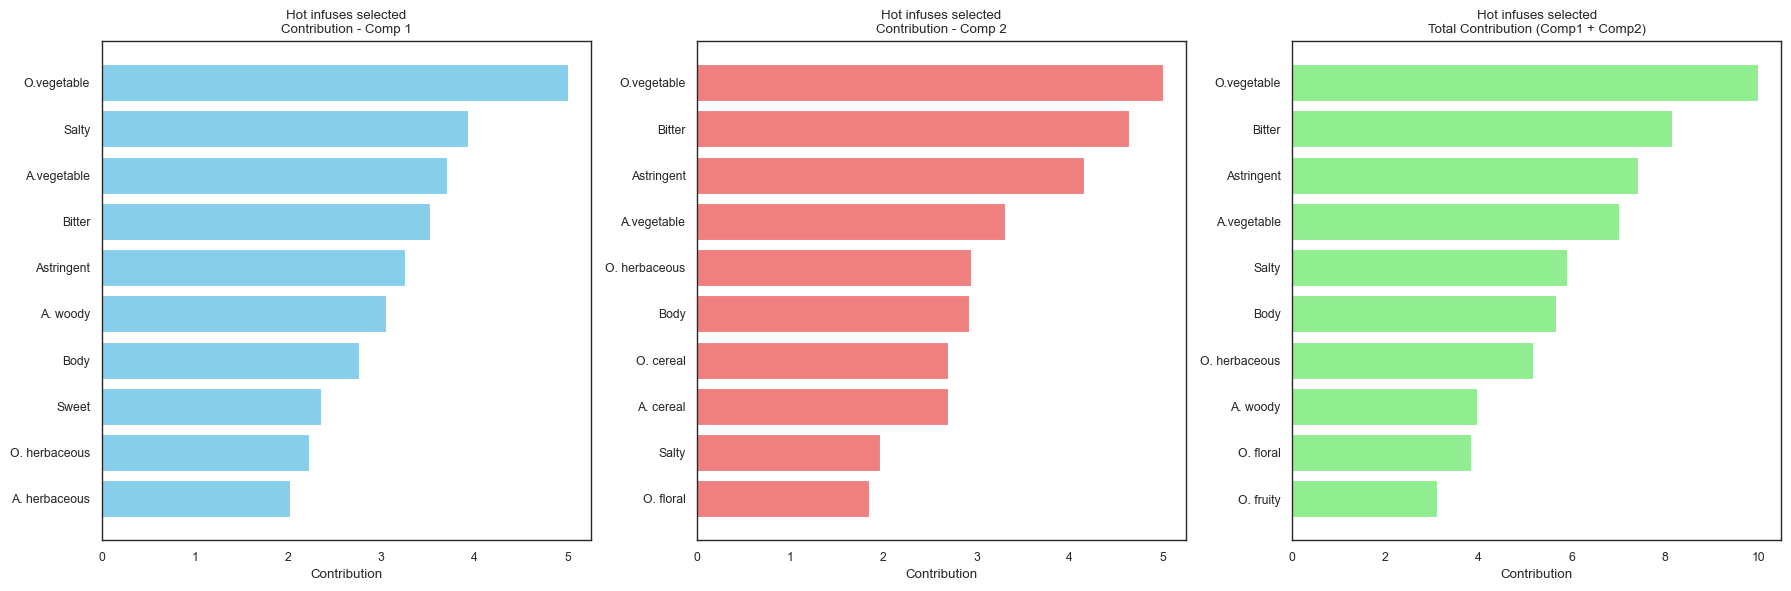


MCA analysis: Cold infuses selected
Sample points analyzed: ['C-MA', 'C-M-EC', 'C-M-T5', 'C-N-GE-WS', 'C-WI']
Explained variance per component:
  Component 1: 31.94%
  Component 2: 26.89%
  Component 3: 22.88%
  Component 4: 18.28%
Total first 2 components: 58.83%


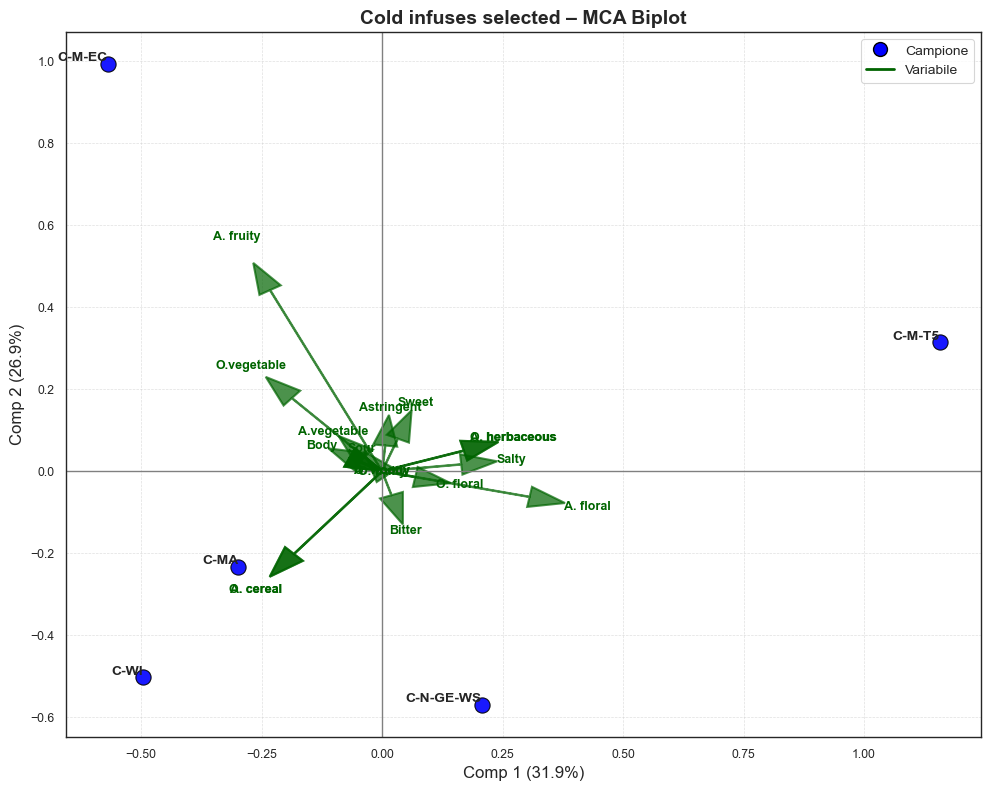


VARIABLE CONTRIBUTIONS

Top 10 variabiles Component 1:
  Astringent: 4.6820
  A. herbaceous: 3.9801
  A. floral: 3.8909
  O. herbaceous: 3.7917
  Salty: 3.6982
  O. floral: 1.6459
  O.vegetable: 1.2165
  Body: 1.0047
  A. fruity: 0.8431
  Bitter: 0.7036

Top 10 variabiles Component 2:
  Astringent: 4.3652
  O.vegetable: 3.2166
  A. fruity: 3.0500
  Bitter: 2.5850
  Sweet: 1.7964
  O. herbaceous: 1.5442
  A. floral: 1.2543
  A. herbaceous: 0.9330
  O. cereal: 0.7824
  A. cereal: 0.7824

Top 10 variabiles Total contribution (Comp1 + Comp2):
  Astringent: 9.0473
  O. herbaceous: 5.3358
  A. floral: 5.1452
  A. herbaceous: 4.9130
  O.vegetable: 4.4331
  Salty: 4.1474
  A. fruity: 3.8932
  Bitter: 3.2886
  Sweet: 2.1021
  O. floral: 1.7147
Salvato: outputs/MCA/cold_selected_top_comp1.csv
Salvato: outputs/MCA/cold_selected_top_comp2.csv


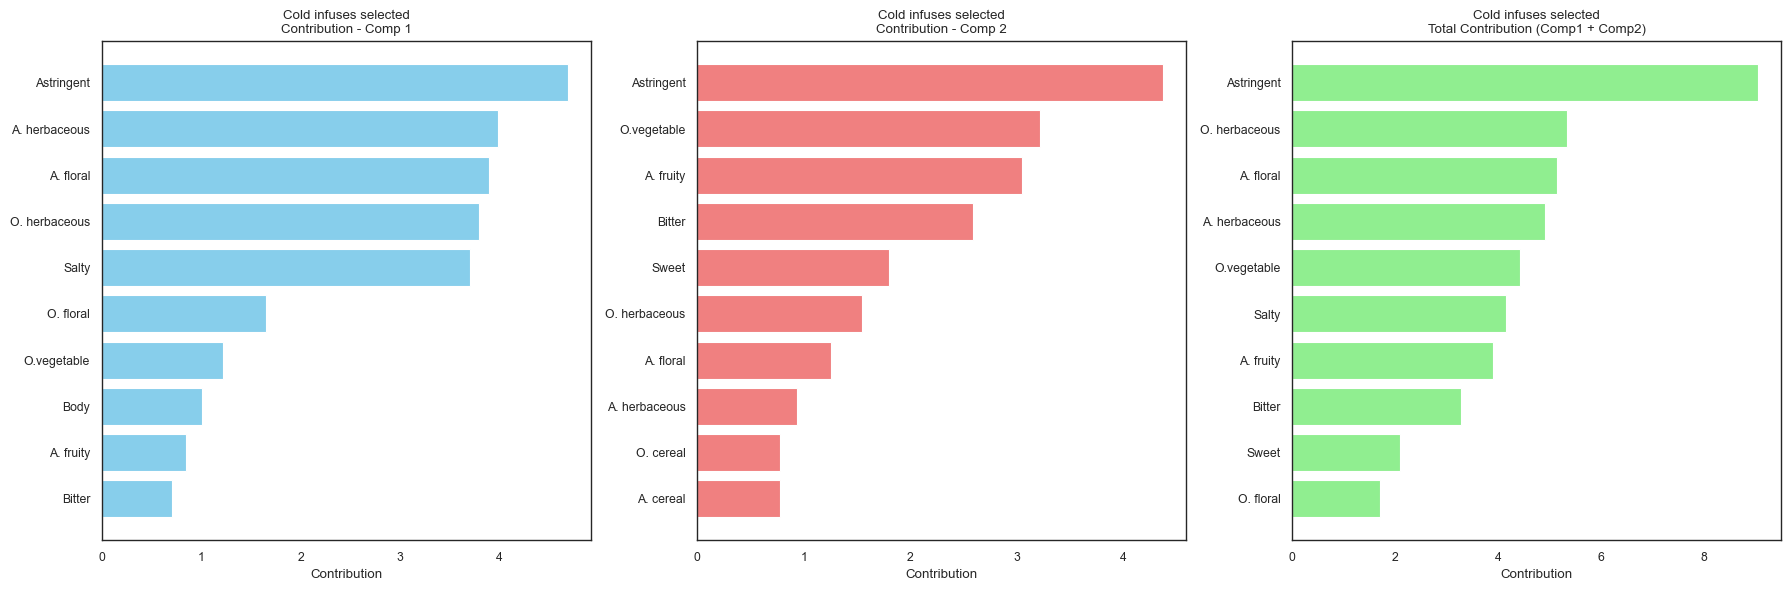

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import prince
import os

# === Data import ===
panel_path = r"c:\Users\david\OneDrive - Università degli Studi di Parma\PhD\Projects\Coffee_leaf_infuses\data\processed\paneldata_infuses_full.csv"
panel_df = pd.read_csv(panel_path, index_col=0)

print("Original dataset:")
print(panel_df.head())
print(f"Shape: {panel_df.shape}")

# === Trasformation 0-5 to 1-6 ===
panel_df = panel_df + 1
print("\nAfter trasformation (0-5 → 1-6):")
print(panel_df.describe())

# === Split hot and cold infusions ===
hot_panel = panel_df[panel_df.index.str.startswith("H-")]
cold_panel = panel_df[panel_df.index.str.startswith("C-")]

print(f"\nHot samples: {len(hot_panel)}")
print(hot_panel.index.tolist())
print(f"\nCold samples: {len(cold_panel)}")
print(cold_panel.index.tolist())

# === Function to calculate variable contributions ===
def calculate_variable_contributions(mca, df_cat, n_components=2):
    col_coords = mca.column_coordinates(df_cat)
    variable_contributions = {}
    
    for var in df_cat.columns:
        var_modalities = [col for col in col_coords.index if col.startswith(f"{var}_")]
        for comp in range(n_components):
            if comp not in variable_contributions:
                variable_contributions[comp] = {}
            contrib = sum([col_coords.loc[mod, comp]**2 for mod in var_modalities if mod in col_coords.index])
            variable_contributions[comp][var] = contrib
    
    return variable_contributions

# === Aggregate coordinates of variables ===
def get_variable_coordinates(mca, df_cat):
    """Calculate the aggregate coordinates of variables as the mean of the coordinates of their modalities"""
    col_coords = mca.column_coordinates(df_cat)
    variable_coords = {}
    for var in df_cat.columns:
        var_modalities = [col for col in col_coords.index if col.startswith(f"{var}_")]
        if var_modalities:
            coords = col_coords.loc[var_modalities].mean(axis=0)
            variable_coords[var] = coords
    return pd.DataFrame(variable_coords).T

# === MCA (all samples) ===
def run_mca(df, title, save_prefix):
    print(f"\n{'='*50}")
    print(f"MCA analysis: {title}")
    print(f"{'='*50}")
    
    df_cat = df.astype(str)
    mca = prince.MCA(n_components=5, n_iter=10, random_state=42).fit(df_cat)

    # Explained variance
    eigenvalues = mca.eigenvalues_
    explained_variance = (eigenvalues / eigenvalues.sum() * 100)
    print("Explained variance per component:")
    for i, var in enumerate(explained_variance[:5]):
        print(f"  Component {i+1}: {var:.2f}%")
    print(f"Total first 2 components: {explained_variance[:2].sum():.2f}%")

    row_coords = mca.row_coordinates(df_cat)
    var_coords = get_variable_coordinates(mca, df_cat)
    
    # Plot
    sns.set_theme(style="white", context="paper")
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Sample points
    sns.scatterplot(x=row_coords.iloc[:, 0], y=row_coords.iloc[:, 1],
                   s=100, edgecolor="black", linewidth=0.8, alpha=0.9,
                   ax=ax, color="tab:blue", label="Sample")
    for i, sample in enumerate(df.index):
        ax.text(row_coords.iloc[i, 0], row_coords.iloc[i, 1], sample,
               fontsize=9, ha='right', va='bottom', weight='bold')

    # Variable arrows
    for var, (x, y) in var_coords.iloc[:, [0, 1]].iterrows():
        ax.arrow(0, 0, x*0.8, y*0.8, color='black', alpha=0.7,
                 head_width=0.05, length_includes_head=True, linewidth=1.5)
        ax.text(x*0.9, y*0.9, var, color='black', fontsize=9,
                ha='center', va='center', weight='bold')
    
    ax.set_title(f"{title} – MCA Biplot", fontsize=14, weight='bold')
    ax.set_xlabel(f"Comp 1 ({explained_variance[0]:.1f}%)", fontsize=12)
    ax.set_ylabel(f"Comp 2 ({explained_variance[1]:.1f}%)", fontsize=12)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    ax.axhline(0, color="grey", lw=1)
    ax.axvline(0, color="grey", lw=1)
    
    from matplotlib.lines import Line2D
    handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue',
               markeredgecolor='black', markersize=8, label='Sample'),
        Line2D([0], [0], color='black', lw=2, label='Variable')
    ]
    ax.legend(handles=handles, loc='best', fontsize=10, frameon=True)
    plt.tight_layout()
    
    os.makedirs("outputs/MCA", exist_ok=True)
    plt.savefig(f"outputs/MCA/{save_prefix}_panel_mca_biplot.jpg", dpi=600, bbox_inches='tight')
    plt.savefig(f"outputs/MCA/{save_prefix}_panel_mca_biplot.svg", bbox_inches='tight')
    plt.show()
    
    return mca, df_cat

# === MCA (on selected samples) ===
selected_samples = [
    "C-MA","C-M-EC","C-M-T5","C-N-GE-WS","C-WI",
    "H-MA","H-M-EC","H-M-T5","H-N-GE-WS","H-WI"
]

def run_mca_selected(df, sample_prefix, title, save_prefix):
    print(f"\n{'='*50}")
    print(f"MCA analysis: {title}")
    print(f"{'='*50}")
    
    filtered = df.loc[[s for s in df.index if s in selected_samples and s.startswith(sample_prefix)]]
    print(f"Sample points analyzed: {filtered.index.tolist()}")
    
    df_cat = filtered.astype(str)
    mca = prince.MCA(n_components=5, n_iter=10, random_state=42).fit(df_cat)
    
    eigenvalues = mca.eigenvalues_
    explained_variance = (eigenvalues / eigenvalues.sum() * 100)
    print("Explained variance per component:")
    for i, var in enumerate(explained_variance[:5]):
        print(f"  Component {i+1}: {var:.2f}%")
    print(f"Total first 2 components: {explained_variance[:2].sum():.2f}%")

    row_coords = mca.row_coordinates(df_cat)
    var_coords = get_variable_coordinates(mca, df_cat)
    
    # Plot
    sns.set_theme(style="white", context="paper")
    fig, ax = plt.subplots(figsize=(10, 8))
    
    color = "red" if sample_prefix == "H" else "blue"
    sns.scatterplot(x=row_coords.iloc[:, 0], y=row_coords.iloc[:, 1],
                   s=120, edgecolor="black", linewidth=0.8, alpha=0.9,
                   ax=ax, color=color, label="Sample")
    for i, sample in enumerate(filtered.index):
        ax.text(row_coords.iloc[i, 0], row_coords.iloc[i, 1], sample,
               fontsize=10, ha='right', va='bottom', weight='bold')
    
    for var, (x, y) in var_coords.iloc[:, [0, 1]].iterrows():
        ax.arrow(0, 0, x*0.8, y*0.8, color='darkgreen', alpha=0.7,
                 head_width=0.05, length_includes_head=True, linewidth=1.5)
        ax.text(x*0.9, y*0.9, var, color='darkgreen', fontsize=9,
                ha='center', va='center', weight='bold')
    
    ax.set_title(f"{title} – MCA Biplot", fontsize=14, weight='bold')
    ax.set_xlabel(f"Comp 1 ({explained_variance[0]:.1f}%)", fontsize=12)
    ax.set_ylabel(f"Comp 2 ({explained_variance[1]:.1f}%)", fontsize=12)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    ax.axhline(0, color="grey", lw=1)
    ax.axvline(0, color="grey", lw=1)
    
    from matplotlib.lines import Line2D
    handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
               markeredgecolor='black', markersize=10, label='Campione'),
        Line2D([0], [0], color='darkgreen', lw=2, label='Variabile')
    ]
    ax.legend(handles=handles, loc='best', fontsize=10, frameon=True)
    plt.tight_layout()
    
    plt.savefig(f"outputs/MCA/{save_prefix}_panel_mca_biplot.jpg", dpi=600, bbox_inches='tight')
    plt.savefig(f"outputs/MCA/{save_prefix}_panel_mca_biplot.svg", bbox_inches='tight')
    plt.show()
    
    # Variable contributions
    print(f"\n{'='*40}")
    print("VARIABLE CONTRIBUTIONS")
    print(f"{'='*40}")
    
    var_contributions = calculate_variable_contributions(mca, df_cat)
    
    comp1_contrib = sorted(var_contributions[0].items(), key=lambda x: x[1], reverse=True)
    comp2_contrib = sorted(var_contributions[1].items(), key=lambda x: x[1], reverse=True)

    print("\nTop 10 variabiles Component 1:")
    for var, contrib in comp1_contrib[:10]:
        print(f"  {var}: {contrib:.4f}")

    print("\nTop 10 variabiles Component 2:")
    for var, contrib in comp2_contrib[:10]:
        print(f"  {var}: {contrib:.4f}")
    
    total_contrib = {var: var_contributions[0][var] + var_contributions[1][var] for var in var_contributions[0]}
    total_sorted = sorted(total_contrib.items(), key=lambda x: x[1], reverse=True)
    
    print("\nTop 10 variabiles Total contribution (Comp1 + Comp2):")
    for var, contrib in total_sorted[:10]:
        print(f"  {var}: {contrib:.4f}")

    # === Esporta dataset CSV con campioni e variabili top per ciascuna componente ===
    def export_top_variables_csv(filtered_df, top_vars, filename):
        df_export = filtered_df[top_vars].copy()
        df_export.insert(0, "Sample", df_export.index)
        df_export.to_csv(f"outputs/MCA/{filename}", index=False)
        print(f"Salvato: outputs/MCA/{filename}")

    # Top 10 variabili per ciascuna componente
    top10_comp1 = [var for var, _ in comp1_contrib[:10]]
    top10_comp2 = [var for var, _ in comp2_contrib[:10]]

    # Esporta per componente 1
    export_top_variables_csv(filtered, top10_comp1, f"{save_prefix}_top_comp1.csv")
    # Esporta per componente 2
    export_top_variables_csv(filtered, top10_comp2, f"{save_prefix}_top_comp2.csv")
    
    # Graphs of contributions
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    vars1, contribs1 = zip(*comp1_contrib[:10])
    axes[0].barh(range(len(vars1)), contribs1, color='skyblue')
    axes[0].set_yticks(range(len(vars1)))
    axes[0].set_yticklabels(vars1)
    axes[0].set_title(f'{title}\nContribution - Comp 1')
    axes[0].set_xlabel('Contribution')
    axes[0].invert_yaxis()
    
    vars2, contribs2 = zip(*comp2_contrib[:10])
    axes[1].barh(range(len(vars2)), contribs2, color='lightcoral')
    axes[1].set_yticks(range(len(vars2)))
    axes[1].set_yticklabels(vars2)
    axes[1].set_title(f'{title}\nContribution - Comp 2')
    axes[1].set_xlabel('Contribution')
    axes[1].invert_yaxis()
    
    vars_tot, contribs_tot = zip(*total_sorted[:10])
    axes[2].barh(range(len(vars_tot)), contribs_tot, color='lightgreen')
    axes[2].set_yticks(range(len(vars_tot)))
    axes[2].set_yticklabels(vars_tot)
    axes[2].set_title(f'{title}\nTotal Contribution (Comp1 + Comp2)')
    axes[2].set_xlabel('Contribution')
    axes[2].invert_yaxis()
    
    plt.tight_layout()
    plt.savefig(f"outputs/MCA/{save_prefix}_variable_contributions.jpg", dpi=600, bbox_inches='tight')
    plt.savefig(f"outputs/MCA/{save_prefix}_variable_contributions.svg", bbox_inches='tight')
    plt.show()
    
    return mca, df_cat

# === Execute ===
print("Creazione cartella outputs...")
os.makedirs("outputs/MCA", exist_ok=True)

mca_hot_all, _ = run_mca(hot_panel, "Hot infuses", "hot_all")
mca_cold_all, _ = run_mca(cold_panel, "Cold infuses", "cold_all")

mca_hot_sel, _ = run_mca_selected(panel_df, "H", "Hot infuses selected", "hot_selected")
mca_cold_sel, _ = run_mca_selected(panel_df, "C", "Cold infuses selected", "cold_selected")